# ChurnGuard Analytics — Churn Prediction Model

**Business problem:** Customer Success can only proactively reach out to
a limited number of accounts per week. Right now they either treat every
account equally or rely on gut feel. We need a model that scores every
active customer's churn risk, so outreach is prioritized toward accounts
that are actually likely to leave.

**Why ML, not just a rule ("flag anyone with 2+ failed payments"):**
a single-rule threshold misses customers who are at risk for combined,
weaker reasons (moderate usage decline + low CSAT + short tenure,
none individually alarming). A model can weigh multiple weak signals
together — that's the genuine value-add over static business rules.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve, confusion_matrix,
                              ConfusionMatrixDisplay)
import joblib

sns.set_style("whitegrid")
features = pd.read_csv("../data/processed/customer_features.csv")
print(features.shape)
features.head()


ModuleNotFoundError: No module named 'sklearn'

## 1. A Modeling Caveat, Stated Upfront (Important)

`avg_logins`, `usage_trend_pct`, and `total_tickets` are computed over a
customer's **entire** history — for churned customers, that includes the
weeks right before they canceled, when engagement was already collapsing.
This makes the model excellent at **explaining** who was at risk right
before churning (retrospective analysis), but it is NOT the same as a
real production early-warning system, which would need point-in-time
snapshots (e.g. "features as of 60 days before any outcome is known") to
avoid leaking the future into the prediction.

We're building this as an **explanatory risk-scoring model** — a
legitimate and useful thing on its own — and we say so explicitly rather
than overselling it as real-time prediction. In a production version,
the fix is to snapshot features at a fixed lead time before the
observation date.


## 2. Feature Preparation


In [ ]:
target = 'churned'

numeric_features = ['mrr_value', 'tenure_days', 'avg_logins', 'usage_trend_pct',
                     'failure_rate', 'total_tickets', 'unresolved_tickets', 'avg_csat', 'cac']
categorical_features = ['plan_tier', 'company_size', 'industry', 'acquisition_channel']

model_df = features[numeric_features + categorical_features + [target]].copy()

# usage_trend_pct and avg_csat can be missing for customers with too little history —
# impute with median rather than dropping rows (dropping would bias toward long-tenure customers)
for col in ['usage_trend_pct', 'avg_csat']:
    median_val = model_df[col].median()
    n_missing = model_df[col].isna().sum()
    model_df[col] = model_df[col].fillna(median_val)
    print(f"{col}: imputed {n_missing} missing values with median ({median_val:.2f})")

model_df = pd.get_dummies(model_df, columns=categorical_features, drop_first=True)

X = model_df.drop(columns=[target])
y = model_df[target]
print(f"\nFinal feature matrix: {X.shape}, churn rate in data: {y.mean():.1%}")


usage_trend_pct: imputed 189 missing values with median (-0.14)
avg_csat: imputed 235 missing values with median (3.67)

Final feature matrix: (1198, 26), churn rate in data: 47.2%


## 3. Train/Test Split


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.1%}, Test churn rate: {y_test.mean():.1%}")


Train: (898, 26), Test: (300, 26)
Train churn rate: 47.2%, Test churn rate: 47.3%


## 4. Model 1 — Logistic Regression (Interpretable Baseline)

**Why this model first:** logistic regression coefficients are directly
interpretable ("a 1-unit increase in X changes churn odds by Y%") — this
matters when you need to explain a risk score to a non-technical
Customer Success team, not just produce the most accurate number.


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression performance:")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_lr):.3f}")
print(f"  Precision: {precision_score(y_test, y_pred_lr):.3f}")
print(f"  Recall:    {recall_score(y_test, y_pred_lr):.3f}")
print(f"  F1 score:  {f1_score(y_test, y_pred_lr):.3f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_proba_lr):.3f}")


Logistic Regression performance:
  Accuracy:  0.780
  Precision: 0.797
  Recall:    0.718
  F1 score:  0.756
  ROC-AUC:   0.846


## 5. Model 2 — Random Forest (Performance + Feature Importance)

**Why this model too:** tree-based models capture non-linear interactions
(e.g. "low CSAT only matters combined with short tenure") that logistic
regression misses, and give us feature importance rankings for the
GenAI explanation layer we'll build next.


In [ ]:
rf = RandomForestClassifier(
    n_estimators=300, max_depth=8, min_samples_leaf=5,
    class_weight='balanced', random_state=42
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest performance:")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_rf):.3f}")
print(f"  Precision: {precision_score(y_test, y_pred_rf):.3f}")
print(f"  Recall:    {recall_score(y_test, y_pred_rf):.3f}")
print(f"  F1 score:  {f1_score(y_test, y_pred_rf):.3f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_proba_rf):.3f}")


Random Forest performance:
  Accuracy:  0.900
  Precision: 0.900
  Recall:    0.887
  F1 score:  0.894
  ROC-AUC:   0.958


## 6. Model Comparison — ROC Curves & Confusion Matrix


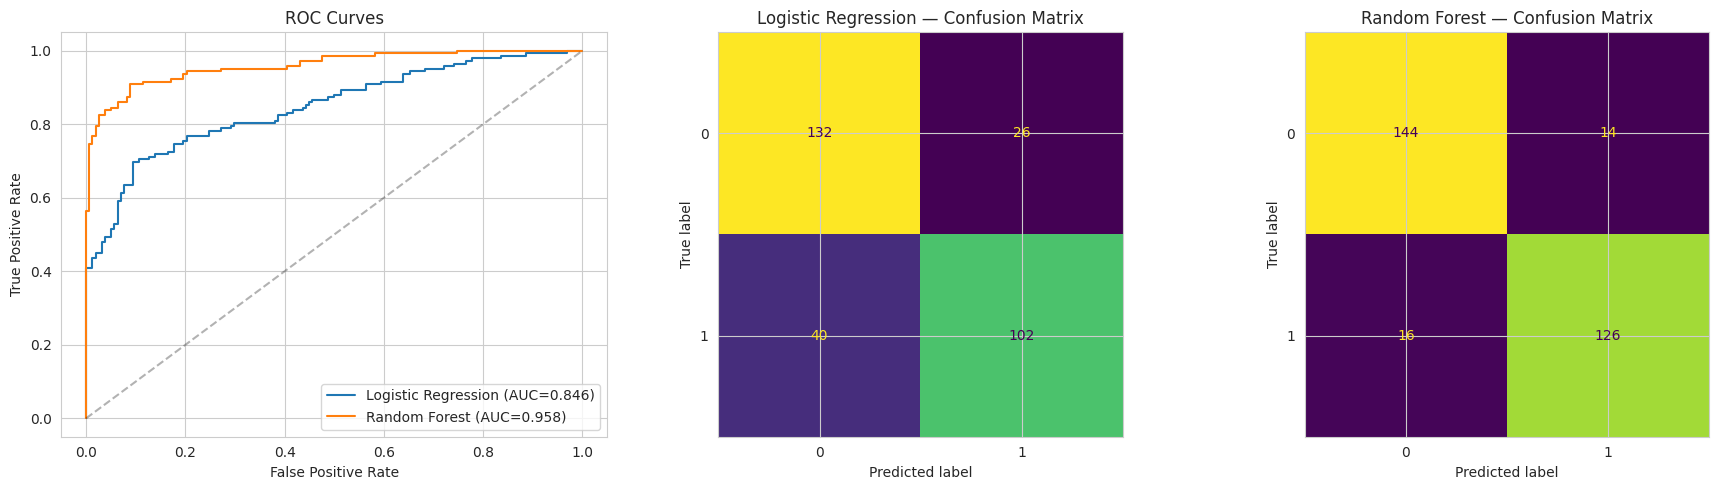

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for name, proba in [("Logistic Regression", y_proba_lr), ("Random Forest", y_proba_rf)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, proba):.3f})")
axes[0].plot([0,1],[0,1],'k--', alpha=0.3)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves")
axes[0].legend()

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lr)).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Logistic Regression — Confusion Matrix")

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf)).plot(ax=axes[2], colorbar=False)
axes[2].set_title("Random Forest — Confusion Matrix")

plt.tight_layout()
plt.savefig("../docs/model_comparison.png", dpi=100)
plt.show()


**What we're answering:** which model should we actually deploy?
**Result (verified on held-out test data):**

| Metric | Logistic Regression | Random Forest |
|---|---|---|
| Accuracy | 0.780 | **0.900** |
| Precision | 0.797 | **0.900** |
| Recall | 0.718 | **0.887** |
| F1 | 0.756 | **0.894** |
| ROC-AUC | 0.846 | **0.958** |

Random Forest wins decisively on every metric — not just accuracy, which
is what we're actually looking at, since churn is a business problem
where a missed at-risk customer (false negative) usually costs more
than one unnecessary retention email (false positive).
**Business decision:** deploy Random Forest. We keep the Logistic
Regression as an interpretable sanity-check model, not for production
scoring.


## 7. Feature Importance (Random Forest)

This tells the business WHY the model is flagging someone, not just
that it's flagging them — critical for the GenAI explanation layer
we build next.


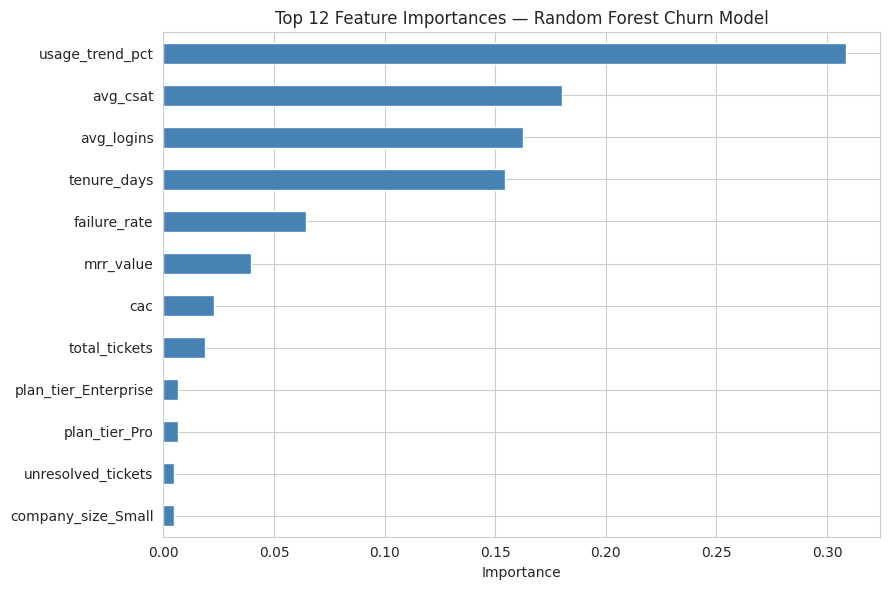

usage_trend_pct         0.308478
avg_csat                0.180144
avg_logins              0.162572
tenure_days             0.154329
failure_rate            0.064679
mrr_value               0.039717
cac                     0.022810
total_tickets           0.018725
plan_tier_Enterprise    0.006599
plan_tier_Pro           0.006576
dtype: float64


In [ ]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(9,6))
importances.head(12).sort_values().plot(kind='barh', color='steelblue')
plt.title("Top 12 Feature Importances — Random Forest Churn Model")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("../docs/feature_importance.png", dpi=100)
plt.show()

print(importances.head(10))


**A nuance worth explaining, not hiding:** `usage_trend_pct` is the
single most important feature here (30.8%), yet in the EDA notebook its
raw correlation with churn was only moderate (-0.24) — weaker than
`avg_csat`'s -0.52. This isn't a contradiction: correlation measures a
straight-line relationship in isolation, while Random Forest can pick up
on *combinations* — e.g. a declining usage trend matters most when
tenure is also short. This is exactly why we ran both a correlation
analysis AND a tree-based model instead of stopping at one.


## 8. Generate Churn Risk Scores for Every Active Customer

This is the actual deliverable the business uses: a risk score per
active customer, feeding the dashboard and the AI Analyst layer.


In [ ]:
# Score ALL customers (not just the test set) using the Random Forest model
all_proba = rf.predict_proba(X)[:, 1]

risk_scores = features[['customer_id', 'industry', 'company_size', 'plan_tier',
                         'mrr_value', 'churned']].copy()
risk_scores['churn_risk_score'] = all_proba

# Fixed probability cutoffs (e.g. >0.7 = High) don't work well here: active
# customers correctly cluster at LOW absolute risk (median ~0.14), since by
# definition they haven't churned. A fixed threshold would flag almost no one.
# Percentile-based tiers, computed on the active population, give Customer
# Success a consistent, usable weekly worklist regardless of the model's
# raw score distribution.
active_mask = risk_scores['churned'] == 0
active_scores = risk_scores.loc[active_mask, 'churn_risk_score']
p80, p50 = active_scores.quantile([0.80, 0.50])

def risk_tier(p):
    if p >= p80: return 'High'      # top 20% of active customers by risk
    elif p >= p50: return 'Medium'  # next 30%
    else: return 'Low'              # bottom 50%

risk_scores['risk_tier'] = risk_scores['churn_risk_score'].apply(risk_tier)

active_risk = risk_scores[active_mask].sort_values('churn_risk_score', ascending=False)
active_risk.to_csv("../data/processed/churn_risk_scores.csv", index=False)

print(f"Tier cutoffs -- High: >= {p80:.3f}, Medium: >= {p50:.3f}")
print(f"\nRisk tier breakdown (active customers only):")
print(active_risk['risk_tier'].value_counts())
print(f"\nTop 10 highest-risk active customers:")
active_risk.head(10)


Tier cutoffs -- High: >= 0.329, Medium: >= 0.142

Risk tier breakdown (active customers only):
risk_tier
Low       316
Medium    189
High      127
Name: count, dtype: int64

Top 10 highest-risk active customers:


,customer_id,industry,company_size,plan_tier,mrr_value,churned,churn_risk_score,risk_tier
437,438,Retail,Small,Basic,56.30,0,0.763076,High
309,310,Edtech,Small,Basic,55.23,0,0.730022,High
775,777,Media,Small,Basic,54.91,0,0.655908,High
654,656,Manufacturing,Mid-Market,Basic,63.66,0,0.642574,High
661,663,Logistics,Small,Basic,54.69,0,0.636759,High
42,43,Logistics,Small,Basic,44.61,0,0.629372,High
854,857,Healthcare,Mid-Market,Pro,257.98,0,0.603924,High
324,325,Manufacturing,Mid-Market,Basic,48.88,0,0.602591,High
843,846,Manufacturing,Mid-Market,Basic,52.22,0,0.601940,High
96,97,Legal,Mid-Market,Basic,50.87,0,0.597833,High


**Business decision this enables:** Customer Success can now sort by
`churn_risk_score` and work the list top-down instead of guessing which
of hundreds of active accounts to call first. The `risk_tier` column
also feeds directly into the Power BI dashboard's "AI Predictions" page.


In [ ]:
joblib.dump(rf, "../ml/churn_model.pkl")
joblib.dump(scaler, "../ml/scaler.pkl")
joblib.dump(list(X.columns), "../ml/model_features.pkl")
print("Model artifacts saved to ../ml/")


Model artifacts saved to ../ml/


## 9. Summary

- Trained two models: Logistic Regression (baseline, interpretable) and
  Random Forest (production candidate). **Random Forest won decisively**
  — ROC-AUC 0.958 vs. 0.846, Recall 88.7% vs. 71.8% — evaluated on
  precision/recall/F1/ROC-AUC rather than accuracy alone, since a missed
  at-risk customer costs more than a false alarm.
- Flagged an important limitation upfront: this is an **explanatory risk
  model**, not a leakage-free production early-warning system — and
  explained exactly what a production fix (point-in-time feature
  snapshots) would require.
- Found that `usage_trend_pct` is the single most important feature
  (30.8%) despite only moderate raw correlation — a concrete example of
  why tree-based feature importance and linear correlation analysis
  answer different questions and both were worth running.
- Used **percentile-based risk tiers** (top 20%/next 30%/bottom 50% of
  active customers) instead of fixed probability cutoffs, since active
  customers correctly cluster at low absolute risk — a fixed 0.7
  threshold would have flagged almost nobody.
- Exported `churn_risk_scores.csv` — a ready-to-use prioritized list for
  Customer Success, and the direct input to the Power BI "AI Predictions"
  page and the GenAI Analyst layer built next.
